Optimization workflow for poloidal field (PF) coil locations in tokamaks
==========

This file allows to obtain in $\textbf{fixed boundary}$ condition the optimal poloidal angle & radial ratios distribution minimizing the electrical currents, given a target equilibrium. DIII-D geometry is here used.

----

## DIII-D equilibria
- $\textbf{g192185.02440}$
- $\textbf{g174864.02500}$
- $\textbf{g173630.03000}$

# Loading libraries

## Useful libraries

In [16]:
import os
import sys
import json
import copy
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import minimize
from helper_functions_angle import resize_polygon, resize_polygon_MANTA, place_points, update_boundary, plot_coil
plt.rcParams['figure.figsize']=(6,6)
#plt.rcParams['font.weight']='bold'
#plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

## Load TokaMaker library
To load the TokaMaker python module we need to tell python where to the module is located. This can be done either through the `PYTHONPATH` environment variable or using within a script using `sys.path.append()` as below, where we look for the environement variable `OFT_ROOTPATH` to provide the path to where the OpenFUSIONToolkit is installed (`/Applications/OFT` on macOS).

For meshing we will use the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain "gs_Domain" class to build a 2D triangular grid suitable for Grad-Shafranov equilibria. This class uses the [triangle code](https://www.cs.cmu.edu/~quake/triangle.html) through a simple internal python wrapper within OFT.

In [17]:
home_dir = os.path.expanduser("~")
oft_root_path = os.path.join(home_dir, "OpenFUSIONToolkit/install_release")
os.environ["OFT_ROOTPATH"] = oft_root_path

tokamaker_python_path = os.getenv("OFT_ROOTPATH")

if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import gs_Domain
from OpenFUSIONToolkit.TokaMaker.util import read_eqdsk, eval_green

# 1. Equilibrium construction with TokaMaker (fixed boundary)

## Create mesh
First we define a target size to set the resolution in our grid. This variable will be used later and represent the target edge size within our mesh, where units are in meters. Note that when setting up a new machine these values will need to scale with the overall size of the device/domain. It is generally a good idea perform a convergence study, by increasing resolution (decreasing target size) by at least a factor of two in all regions, when working with a new geometry to ensure the results are not sensitive to your choice of grid size.

### Define boundary

In [18]:
# Loading machine LCFS & shot from EQDSK file
mesh_dx = 0.015 # DIIID
eqdsk = read_eqdsk('g192185.02440') # Machine shot
LCFS_contour = eqdsk['rzout'].copy()

### Define regions, attributes & geometry for region boundaries
We now create the mesh object and define the various logical mesh regions. In this case we only have one region, which is named `plasma` and is of type `plasma`. 

In [19]:
# Create a G-S domain
gs_mesh = gs_Domain()

# Define region information for mesh
gs_mesh.define_region('plasma',mesh_dx,'plasma')

# Define mesh geometry 
gs_mesh.add_polygon(LCFS_contour,'plasma')

### Generate mesh & plotting resulting regions and grid
Now we generate the actual mesh using the \ref OpenFUSIONToolkit.TokaMaker.gs_Domain.build_mesh "build_mesh" method. This step may take a few moments as [triangle](https://www.cs.cmu.edu/~quake/triangle.html) generates the mesh.

Note that, as is common with unstructured meshes, the mesh is stored a list of points `mesh_pts` of size (np,2), a list of cells formed from three points each `mesh_lc` of size (nc,3), and an array providing a region id number for each cell `mesh_reg` of size (nc,), which is mapped to the names above using the `coil_dict` and `cond_dict` dictionaries.

In [20]:
mesh_pts, mesh_lc, mesh_reg = gs_mesh.build_mesh()

Assembling regions:
  # of unique points    = 294
  # of unique segments  = 2
Generating mesh with Triangle:
  # of points  = 9280
  # of cells   = 18264
  # of regions = 1


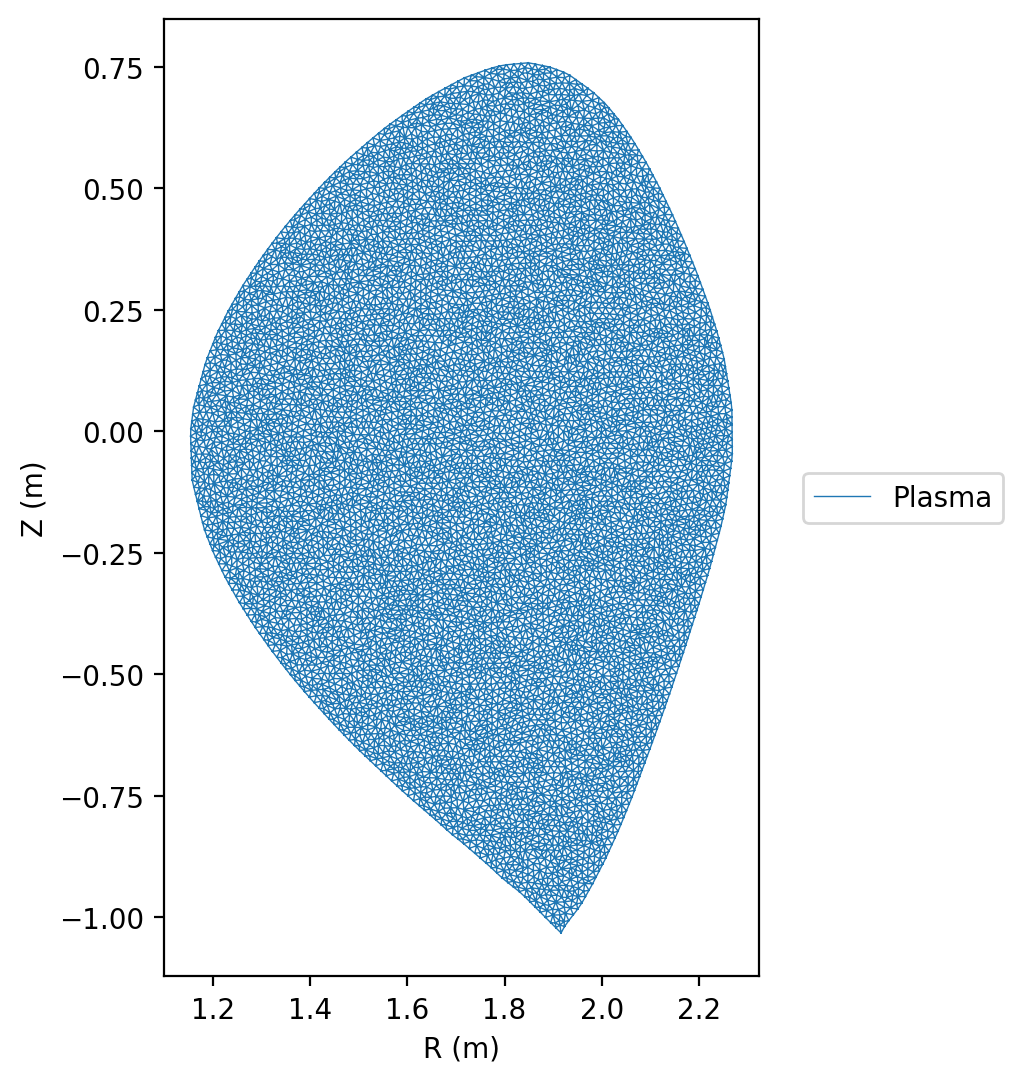

In [21]:
# Machine region and grid
fig, ax = plt.subplots(1,1,figsize=(5,8),constrained_layout=True)
gs_mesh.plot_mesh(fig,ax)

## Compute equilibria

### Initialize TokaMaker object
First we create a TokaMaker instance to use for equilibrium calculations. Note at present only a single instance can be used per python kernel, so this command should only be called **once** in a given Jupyter notebook or python script.

In [22]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:   main
Revision id:          e2083e8
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/oft_56968/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



### Load mesh into TokaMaker
Now we load the mesh generated above using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup_mesh "setup_mesh" and set the code to operate in $\textbf{fixed boundary}$ mode by setting the `free_boundary` setting to False. Finally, we call \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.setup "setup" to setup the required solver objects. During this call we can specify the desired element order (min=2, max=4) and the toroidal field through F0 = B0*R0, where B0 is the toroidal field at a reference location R0.

In [23]:
mygs.setup_mesh(mesh_pts,mesh_lc)
mygs.settings.free_boundary = False

F0 = eqdsk['rcentr'] * eqdsk['bcentr']
mygs.setup(order=2,F0=F0)


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.325E+00
    # of points  =    9280
    # of edges   =   27543
    # of cells   =   18264
    # of boundary points =     294
    # of boundary edges  =     294
    # of boundary cells  =     294
  Resolution statistics:
    hmin =  9.309E-03
    hrms =  1.366E-02
    hmax =  2.307E-02
  Surface grounded at vertex       7


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1



### Define global quantities and targets
For the Grad-Shafranov solve we define targets for the plasma current and the pressure.

In [24]:
Ip_target = eqdsk['ip']
pres_target = eqdsk['pres'][0]
mygs.set_targets(Ip=Ip_target, pax=pres_target)

### Initialize the flux function & compute a fixed-boundary equilibrium
Before running a calculation for the first time we must initialize the flux function $\psi$, which can be done using \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.init_psi "init_psi". By default this calculation uses a uniform current (equal to Ip_target) over the full plasma domain. Then we can compute an equilibrium in this geometry.

In [25]:
# flux function initialization
err_flag = mygs.init_psi()

# Computing the equilibrium
err_flag = mygs.solve()

Starting non-linear GS solver
     1  7.4958E-01  8.5761E-02  3.9807E-04  1.7868E+00 -4.0473E-02  0.0000E+00
     2  9.0890E-01  6.8636E-02  1.2691E-04  1.7821E+00 -4.0418E-02  0.0000E+00
     3  9.4714E-01  6.4809E-02  4.5446E-05  1.7796E+00 -4.0324E-02  0.0000E+00
     4  9.5804E-01  6.3765E-02  1.7290E-05  1.7785E+00 -4.0247E-02  0.0000E+00
     5  9.6136E-01  6.3458E-02  6.7285E-06  1.7780E+00 -4.0196E-02  0.0000E+00
     6  9.6241E-01  6.3363E-02  2.6313E-06  1.7778E+00 -4.0167E-02  0.0000E+00
     7  9.6275E-01  6.3333E-02  1.0281E-06  1.7777E+00 -4.0151E-02  0.0000E+00
     8  9.6286E-01  6.3323E-02  4.0095E-07  1.7777E+00 -4.0143E-02  0.0000E+00
 Timing:  0.34364700000151061     
   Source:    0.22180699993623421     
   Solve:      8.6070000019390136E-002
   Boundary:   7.0920000434853137E-003
   Other:      2.8678000002400950E-002


### Print information and plot equilibrium
After computing the equilibrium, basic parameters can be displayed using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.print_info "print_info" method. For access to these quantities as variables instead the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.get_stats "get_stats" can be used.

Flux surfaces can be plotted using the \ref OpenFUSIONToolkit.TokaMaker.TokaMaker.plot_psi "plot_psi" method. Additional plotting methods are also available to display other information for more complex cases. See other examples and the documentation for more information.

Equilibrium Statistics:
  Topology                =   Limited
  Toroidal Current [A]    =    4.9332E+05
  Current Centroid [m]    =    1.737 -0.051
  Magnetic Axis [m]       =    1.778 -0.040
  Elongation              =    1.602 (U:  1.433, L:  1.771)
  Triangularity           =   -0.302 (U: -0.246, L: -0.359)
  Plasma Volume [m^3]     =   14.542
  q_0, q_95               =    2.842  5.677
  Plasma Pressure [Pa]    =   Axis:  6.8215E+03, Peak:  6.8215E+03
  Stored Energy [J]       =    5.1004E+04
  <Beta_pol> [%]          =   29.9308
  <Beta_tor> [%]          =    0.1633
  <Beta_n>   [%]          =    0.3498
  Diamagnetic flux [Wb]   =    5.2050E-03
  Toroidal flux [Wb]      =    2.5316E+00
  l_i                     =    0.8030


Text(0, 0.5, '$Z$ [m]')

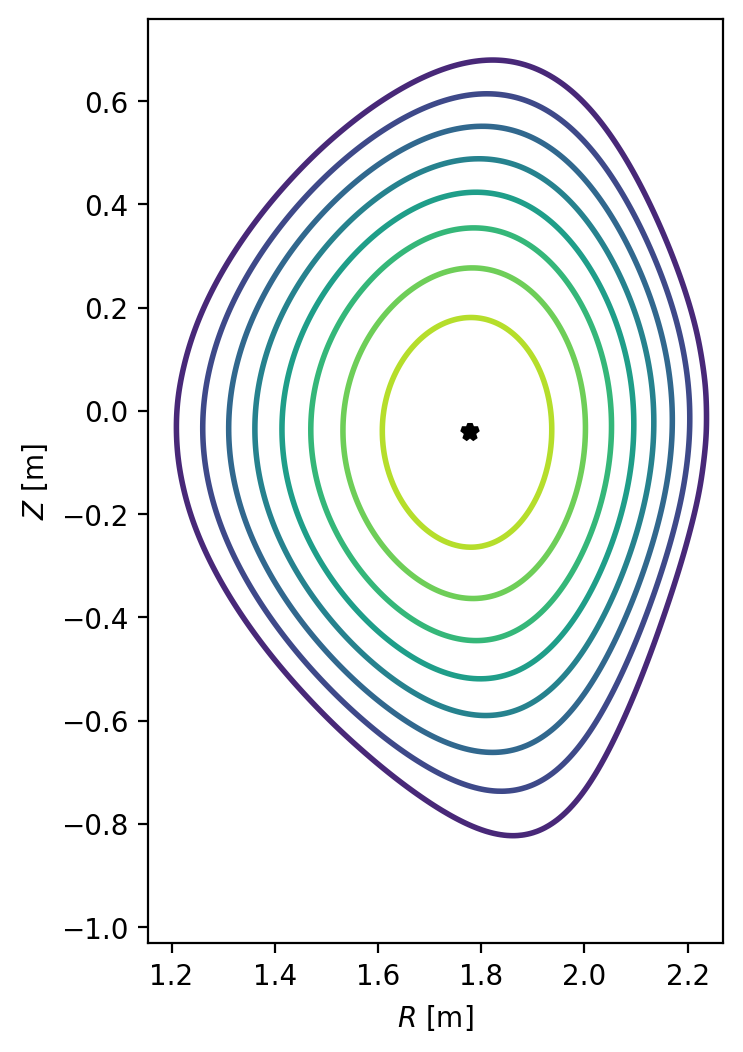

In [26]:
mygs.print_info()

# Plot flux surfaces
fig, ax = plt.subplots(1,1)
mygs.plot_psi(fig,ax, plasma_nlevels=10)
plt.xlabel('$R$ [m]')
plt.ylabel('$Z$ [m]')
#plt.title('DIII-D')

In [27]:
# will be one of the targets for the free-boundary case
fixed_mag_axis = mygs.o_point.copy()
fixed_mag_axis

array([ 1.77765079, -0.04014293])

## Boundary flux

- $r\_bnd$ represents the (R, Z) coord. along the fixed boundary where vacuum flux is evaluated (shape (n, 2))
- $psi\_bnd$ represents the required vacuum flux for balancing the fixed boundary equilibrium, at each of those boundary positions

Computing fixed boundary vacuum flux
 Computing flux BC matrix 
 Inverting real matrix
   Time =    2.6646000000000000E-002
 Starting LU solver: umfpack T


Text(0.5, 1.0, 'DIII-D')

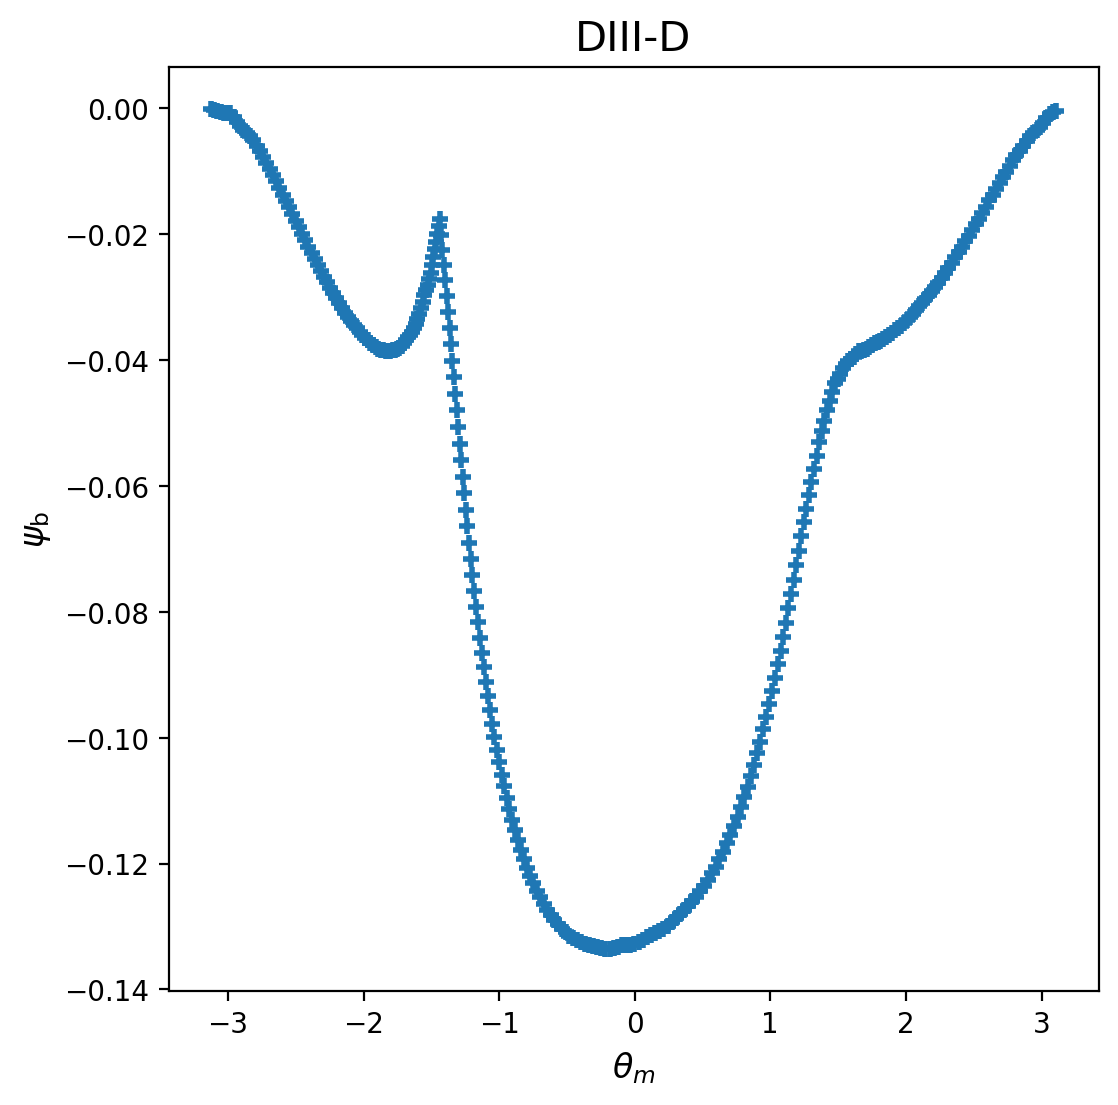

In [28]:
r_bnd, psi_bnd = mygs.get_vfixed()

# Plot required relative flux on boundary
fig, ax = plt.subplots()
theta = np.arctan2(r_bnd[:,1],r_bnd[:,0]-mygs.o_point[0])
_=ax.plot(theta[1:],psi_bnd[1:]-psi_bnd[0],'+')
plt.xlabel(r"$\theta_{m}$", fontsize=12)
plt.ylabel(r'$\psi_{\text{b}}$', fontsize=12)
plt.title('DIII-D', fontsize=15)

# 2. Optimization process

## Coil position space & machine geometry

The following cell creates the bounds defining the $\textbf{coil position space}$ (CPS). The latter is defined as the area between the curves `coil_center_cand1` & `coil_center_cand2`. Tune these 2 variables to modify the CPS. `dx` can be tuned to adjust the distance of the bounds.

update_boundary() is used here to generated the CPS bounds, but other methods can be used as PlotDigitizer.

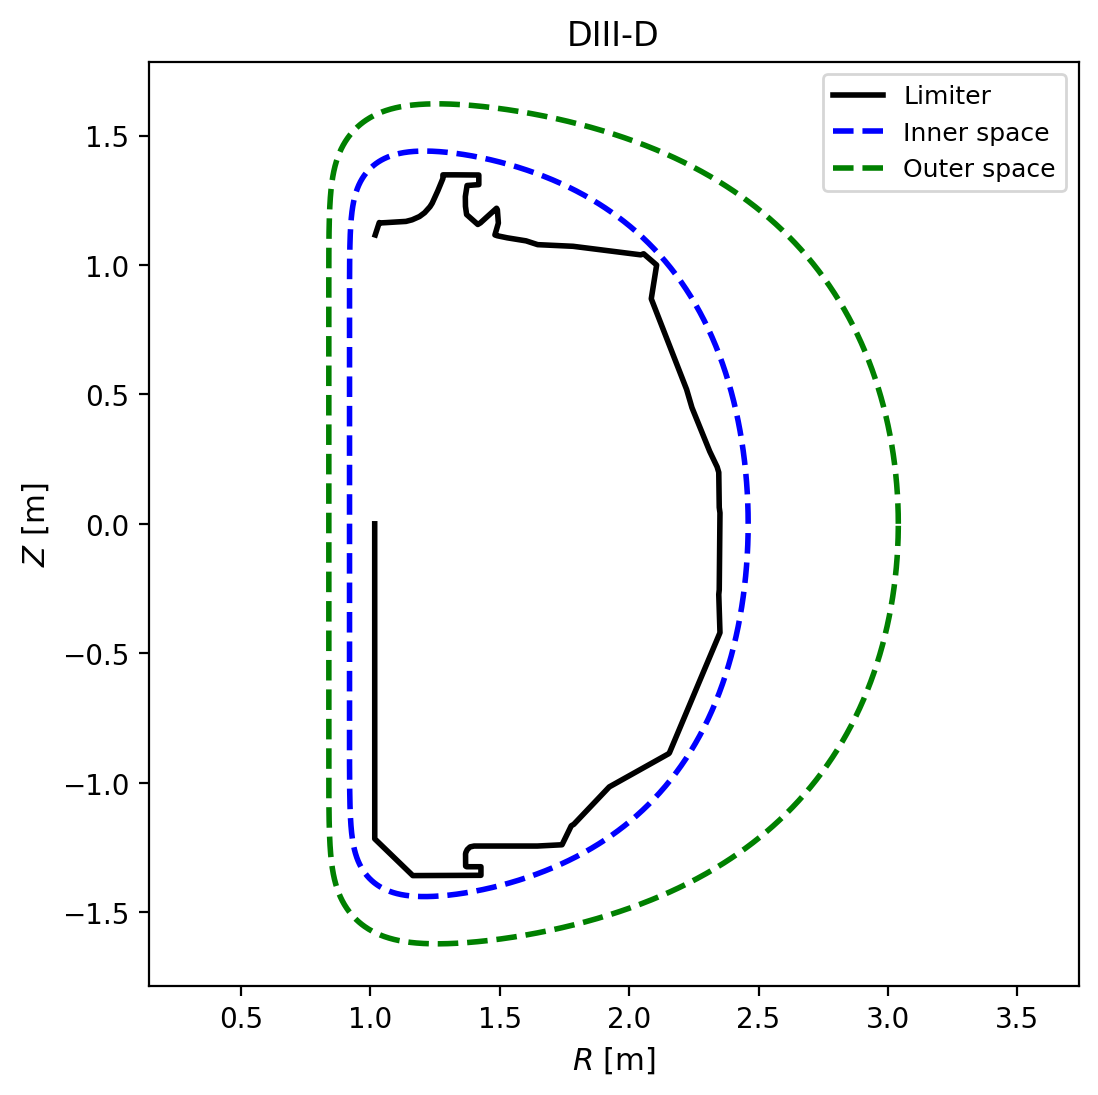

In [29]:
# Geometry
with open('DIIID_geom.json','r') as fid:
    DIIID_geom = json.load(fid)

# Get the machine limiter
lim0 = np.array(DIIID_geom['limiter'])

# Generates a simplified limiter (return a list of (R,Z) coord of plasma bound.)
lim = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=1700) 


# inner position space
lim1 = update_boundary(r0=1.69, z0=0, a0=0.67, kappa=2, delta=0.8, squar=0.15, npts=1700) 
coil_center_cand1 = resize_polygon(lim1, dx=0.1)

# outer position space
lim2 = update_boundary(r0=1.94, z0=0, a0=0.95, kappa=1.55, delta=0.8, squar=0.15, npts=1700) 
coil_center_cand2 = resize_polygon(lim2, dx=0.15)     

# Plot geometry & coil position space
plt.figure(figsize=(6, 6))
plt.plot(lim0[:,0], lim0[:,1], 'k', label='Limiter')
# plt.plot(lim[:,0], lim[:,1], 'r--', label='Simpler limiter')
plt.plot(coil_center_cand1[:,0], coil_center_cand1[:,1], 'b--', label='Inner space')
plt.plot(coil_center_cand2[:,0], coil_center_cand2[:,1], 'g--', label='Outer space')

plt.title('DIII-D')
plt.xlabel('$R$ [m]', fontsize=11)
plt.ylabel('$Z$ [m]', fontsize=11)
plt.axis('equal')
plt.legend(fontsize=9)

In [30]:
def place_points_pol_rad(ncoils, arc_inner, arc_outer, pol_angles, radials):
    """
    Places coils inside a strip defined by two curves (arc_inner, arc_outer)
    based on poloidal angle and radial offset.

    Parameters:
        - ncoils: (int) Number of coils in upper side
        - arc_inner: (ndarray (N,2)) Inner curve coordinates (R,Z) 
        - arc_outer: (ndarray (N,2)) Outer curve coordinates (R,Z)
        - pol_angles: Poloidal angles (degrees)
        - radials: Radial ratios

    Returns: 
        - inds: (ndarray) Indices along the arc (based on arc_inner indexing)
        - locs: (ndarray (npoints, 2)) Coil (R, Z) coordinates
    """
    if len(pol_angles) != ncoils or len(radials) != ncoils:
        raise ValueError("Length of pol_angles and radials must match ncoils.")

    # Create a mapping from poloidal angle to index along arc
    theta_range = np.linspace(0, 180, len(arc_inner))  # top half
    pol_angles = np.asarray(pol_angles)

    inds = []
    locs = []

    for theta, rho in zip(pol_angles, radials):
        # Interpolate R and Z along each arc at this theta
        R_inner = np.interp(theta, theta_range, arc_inner[:, 0])
        Z_inner = np.interp(theta, theta_range, arc_inner[:, 1])
        R_outer = np.interp(theta, theta_range, arc_outer[:, 0])
        Z_outer = np.interp(theta, theta_range, arc_outer[:, 1])

        # Interpolate between inner and outer curves based on rho
        R_pos = (1 - rho) * R_inner + rho * R_outer
        Z_pos = (1 - rho) * Z_inner + rho * Z_outer

        # Approximate index based on inner arc position
        idx = int(np.interp(theta, theta_range, np.arange(len(arc_inner))))

        inds.append(idx)
        locs.append([R_pos, Z_pos])

    return np.array(inds), np.array(locs)

In [31]:
def make_new_coils(params, nCoils, dx=0.08, dy=0.08, params2=None, ifplot=True):
    """
    Generates and places poloidal field (PF) coils given their poloidal angles and radial ratios. 
    It creates a set of coil pairs (one above and one below the midplane) whose size can be changed 
    thanks to dx & dy. Optionally plots two coil configurations.

    Parameters:
        - params: List of poloidal angles (degrees) and their radial ratios (between 0 and 1)
        - nCoils: Number of coils (in the top-side)
        - dx: Horizontal coil size
        - dy: Vertical coil size
        - params2: (Optional) Second list of poloidal angles and radial ratios
        - ifplot: (Boolean) boolean whether to plot the given coil distribution

    Returns:
        - scan_geom: (Dict) Dictionary containing the data of the coil distr.
    """
    # Loading poloidal angles (thetas) and radial ratios (radials)
    thetas = params[:nCoils]
    radials = params[nCoils:2*nCoils]
    
    # Creating dict.
    scan_geom = {}
    scan_geom["coils"] = {}
    
    # Defining coil locations for the first distribution (2nd arg is just the top-side of coil_center_cand)
    inds, locs = place_points_pol_rad(nCoils, coil_center_cand1[:len(coil_center_cand1)//2,:], coil_center_cand2[:len(coil_center_cand2)//2,:], thetas, radials)
    
    # Creating coil pairs for (1st) distribution
    for i, loc in enumerate(locs):
        pts_top = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                            [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
        pts_bot = pts_top * np.array([1, -1])

        # Storing coils
        scan_geom["coils"][f'F{i}A'] = {'pts': copy.deepcopy(pts_top), 'nturns': 1.0}
        scan_geom["coils"][f'F{i}B'] = {'pts': copy.deepcopy(pts_bot), 'nturns': 1.0}

    # Plotting the coil distribution
    if ifplot:
        plt.figure(figsize=(6, 10))
        ax = plt.subplot(111)
        ax.axis('equal')

        # Plot the limiter
        plt.plot(np.hstack((lim0[:, 0], lim0[0, 0])), np.hstack((lim0[:, 1], lim0[0, 1])), c='k')
        #plt.plot(lim1[:, 0], lim1[:, 1], c='k', ls=':')

        # Plot the first set of coils
        for coil in scan_geom["coils"]:
                pts = np.array(scan_geom["coils"][coil]['pts'])
                plot_coil(pts, ax) 
                #plt.text(np.average(pts[:, 0]), np.average(pts[:, 1]), coil, ha='center', va='center')

        ax.set_xlabel('$R$ [m]')
        ax.set_ylabel('$Z$ [m]')

        # If provided, plot the (2nd) distrib in red
        if params2 is not None:
            thetas2 = params2[:nCoils]
            radials2 = params2[nCoils:2*nCoils]

            scan_geom_2 = {}
            scan_geom_2["coils"] = {}
            inds2, locs2 = place_points_pol_rad(nCoils, coil_center_cand1[:len(coil_center_cand1)//2,:], coil_center_cand2[:len(coil_center_cand2)//2,:], thetas2, radials2)

            for i, loc in enumerate(locs2):
                pts_top2 = np.array([[loc[0]-dx, loc[1]+dy], [loc[0]+dx, loc[1]+dy], 
                                     [loc[0]+dx, loc[1]-dy], [loc[0]-dx, loc[1]-dy]])
                pts_bot2 = pts_top2 * np.array([1, -1])

                # Storing second set of coils, oF -> just name for the 2nd distrib
                scan_geom_2["coils"][f'F{i}A'] = {'pts': copy.deepcopy(pts_top2), 'nturns': 1.0}
                scan_geom_2["coils"][f'F{i}B'] = {'pts': copy.deepcopy(pts_bot2), 'nturns': 1.0}

            # Plot the second set of coils 
            for coil in scan_geom_2["coils"]:
                    pts2 = np.array(scan_geom_2["coils"][coil]['pts'])
                    plot_coil(pts2, ax)  
                    ax.plot(pts2[:, 0], pts2[:, 1], 'r')
                    #plt.text(np.average(pts2[:, 0]), np.average(pts2[:, 1]), coil, ha='center', va='center', color='r')

        ax.set_xlabel('$R$ [m]')
        ax.set_ylabel('$Z$ [m]')


    return scan_geom

## Core functions

In [32]:
def compute_coil_centers(scan_geom):
    """
    Compute the center of each coils

    Parameter: 
        - scan_geom: (Dict) dictionary with coils informations
        
    return:   
        - coil_centers: (2D array, (R,Z) positions) Coils centers of both top & bottom side 
    """
    coil_centers = []

    # Loading and computing the mean of coil edges for each coil
    for i, coil in enumerate(scan_geom["coils"]):
        pts = np.array(scan_geom["coils"][coil]["pts"])
        center = np.mean(pts, axis=0) 

        # Store the center as a pair (for a single coil)
        coil_centers.append(np.asarray([center]))  # Each element is a 2D array with one center

    return coil_centers

In [33]:
def make_3x3_thick(center, R):
    """
    Generate the centers of 9 tangent cables forming a 3x3 coil.

    Parameters:
    - center: (R, Z) coord. of the central filament
    - R: Coil filament radius 

    Returns:
    - fil_centers: List of (R, Z) coord. for each cable center
    """
    R0, Z0 = center
    offsets = [-1, 0, 1]
    fil_centers = []

    # scanning the grid
    for dx in offsets:
        for dy in offsets:
            fil_centers.append([R0 + 2 * R * dx, Z0 + 2 * R * dy])

    return fil_centers

In [34]:
def opt_PFcoil_loc(param, omega, dist_th, bounds=None, Rfil=0.01, reg_in=1e-9, BFGS=True, plot_err=False, plot_info=True):
    """
    Performs an outer-loop optimization over the poloidal coil positions with regularization terms. 
    For each configuration, it solves an inner loop (Least-Squares problem) in order to get 
    the optimal coil currents that minimize the flux error on the boundary. Then, the final error 
    from this inner problem is used as the cost function for optimizing coil locations. 

    Arguments:
        - param: List of poloidal angles (degrees) and their radial ratios (between 0 and 1)
        - omega: Regularization term related to coil distance
        - dist_th: Distance threshold between coils (in degrees)
        - bounds: Specify the bounds in which each poloidal angle and radial ratio can vary (list)
        - Rfil: Coil filament radius 
        - reg_in: Regularization term in inner loop constraining the currents
        - plot_err: if True, plot the error w.r.t to the current optimization

    Returns:
        - result.x: Optimized coil positions as an array of poloidal angles in top-side (degrees)
        - result.fun: Final cost of the outer loop
        - final_currs: Optimized currents (top & bottom side)
    """
    # Number of coils in the upper part
    num_coils = len(param) // 2

    # Storing final results
    final_currs = None 
    final_con = None    
    inner_cost = None

    nb_iter = 0
    curr_cost = 0

    def objective(pol_ratio_distr):
        """
        Objective function for optimizing coil locations. It first determines the best coil currents for a 
        given coil config, then returns the corresponding cost solving a Least-squares problem.
        
        Arguments:
            - pol_ratio_distr: List of poloidal angles in top-side (degrees) and their radial ratios (between 0 and 1) 
        
        Returns:
            -  final_cost[0]: Cost function value based on optimal currents for the given positions
        """
        # To be accessible outside this function
        nonlocal final_currs, final_con, inner_cost, nb_iter, curr_cost

        nb_iter += 1 

        # Loading new coil configuration (name, positions, etc)
        scan_geom_DIIID = make_new_coils(pol_ratio_distr, num_coils, ifplot=False)

        # Compute coil centers
        new_coil_center = compute_coil_centers(scan_geom_DIIID)

        # Add 3x3 thickness to each coil
        new_coil_center_3x3 = []

        for i, center in enumerate(new_coil_center):
            thick_centers = make_3x3_thick(center[0], Rfil)
            new_coil_center_3x3.append(thick_centers)

        ### Least Squares ###############     
        con = np.zeros((psi_bnd.shape[0]+len(new_coil_center_3x3)-1, len(new_coil_center_3x3)))
        
        for i, filament_set in enumerate(new_coil_center_3x3):
            flux_tmp = np.zeros((psi_bnd.shape[0],))
            for fil in filament_set:
                flux_tmp += eval_green(r_bnd, fil)
            con[:psi_bnd.shape[0]-1,i] = flux_tmp[1:] - flux_tmp[0]
            con[psi_bnd.shape[0]-1+i,i] = reg_in # Regularization term

        # Performs least-squares fit
        err = np.zeros((psi_bnd.shape[0]+len(new_coil_center_3x3)-1,))
        err[:psi_bnd.shape[0]-1] = psi_bnd[1:] - psi_bnd[0]
        currs, final_cost, _, _ = np.linalg.lstsq(con, err, rcond=None)
        #print("final cost inner loop: ", final_cost[0])
        #################################
        
        # Store the final currents, con matrix & inner cost
        final_currs = currs
        final_con = con    
        inner_cost = final_cost[0].copy()

        ##### Distance penalty constraint #######    
        dist_angles = np.diff(pol_ratio_distr[:len(pol_ratio_distr)//2])
        pen_terms = np.maximum(dist_th - dist_angles, 0.0) ** 2
        dist_pen = omega * np.sum(pen_terms)
        
        # print(f"iteration {nb_iter}, current distribution: {pol_ratio_distr}, current cost: {final_cost}")

        if BFGS:
            return inner_cost + dist_pen
        else:
            return inner_cost + dist_pen, final_currs
    
    if BFGS:
        # (outer loop) Coil position optimization
        result = minimize(objective, param, method='L-BFGS-B', bounds=bounds, options={'disp': True})#, 'ftol': 1e-10})

        # flux error
        psi_prime = psi_bnd[1:] - psi_bnd[0]
        psi_computed = np.dot(final_con, final_currs)[:psi_bnd.shape[0] - 1]
        flux_err = np.linalg.norm(psi_prime - psi_computed)**2

        # Plot flux comparison
        if plot_err == True:
            # Ensure final_con is not None before plotting
            if final_con is not None and final_currs is not None:
                fig, ax = plt.subplots()
                ax.plot(theta[1:], psi_bnd[1:] - psi_bnd[0], 'o', label="Boundary flux")
                ax.plot(theta[1:], np.dot(final_con, final_currs)[:psi_bnd.shape[0] - 1], '+', label="Computed Flux")
                # Add reg_in to legend
                ax.plot([], [], ' ', label=fr"$\lambda_{{\mathrm{{in}}}} = {reg_in:.1e}$")
                ax.set_xlabel("$\Theta$", fontsize=12)
                ax.set_ylabel("boundary flux")
                ax.legend()
        
        if plot_info is True:
            # Print outer loop informations
            print("outer cost: ", result.fun)
            print("inner cost: ", inner_cost)
            print("number of iterations for the outer loop: ", result.nit)
            print("success: ", result.success)
            print("status: ", result.status)
            print("message: ", result.message)
            #print("check cost", objective(result.x))

        return result.x, result.fun, final_currs, inner_cost, flux_err
    else:
        return objective(param)

<>:114: SyntaxWarning: invalid escape sequence '\T'
<>:114: SyntaxWarning: invalid escape sequence '\T'
/var/folders/z5/d2ytmy3d2h18qcqwb9v71w2m0000gq/T/ipykernel_56968/1424371212.py:114: SyntaxWarning: invalid escape sequence '\T'
  ax.set_xlabel("$\Theta$", fontsize=12)


# 3. Example

Here is a simple example using the optimization scheme `opt_PFcoil_loc()`. As the function to be minimized can contained several local minima, it can be useful to generate more initial guesses. The initial guess `param_list` is here defined as poloidal angle & radial ratios. The optimized distribution of PF coils and associated radial ratios are given in `opt_distr`. Take the latter as input for the free boundary case. The outer & inner costs are also returned and should be the same.

In addition, `reg_in` is also an important parameter to be tuned. The latter can affect a lot the optimized currents and the final cost. $\textbf{Important observation}$: a lower cost doesn't necessarily mean lower optimized currents. If the optimized coils are too close to each other, increase `omega`. 

$\textbf{To fix a coil}$ during the optimizing, impose its fixed position with `bounds`. For example, to fix the first coil to 20° on the inner curve, choose (20, 20) for its associated angle bound and (0, 0) for its ratio bound. (see commented code below). Adapt the other bounds to avoid overlaps.

### Parameter ranges:

- `reg_in`: Regularization for currents, 1e-8 - 1e-5
- `omega`: Weight for coil spacing, 1e-7 - 1e-3
- `dist_th`: Target min. coil gap [°], 3 - 10

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           10     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.93163D-04    |proj g|=  5.30381D-04

At iterate    1    f=  3.92576D-04    |proj g|=  5.29325D-04

At iterate    2    f=  2.38245D-04    |proj g|=  2.86094D-04

At iterate    3    f=  1.89607D-04    |proj g|=  1.36558D-04

At iterate    4    f=  1.64292D-04    |proj g|=  7.51758D-05

At iterate    5    f=  1.45454D-04    |proj g|=  6.39329D-05

At iterate    6    f=  1.28905D-04    |proj g|=  5.37267D-05

At iterate    7    f=  8.80906D-05    |proj g|=  5.48790D-05

At iterate    8    f=  8.27952D-05    |proj g|=  7.96702D-05

At iterate    9    f=  7.97419D-05    |proj g|=  2.51102D-05
outer cost:  7.898171847925814e-05
inner cost:  7.898171847741151e-05
number of iterations for the outer loop:  10
success:  True
status:  0
message:  CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL

initial:  [5

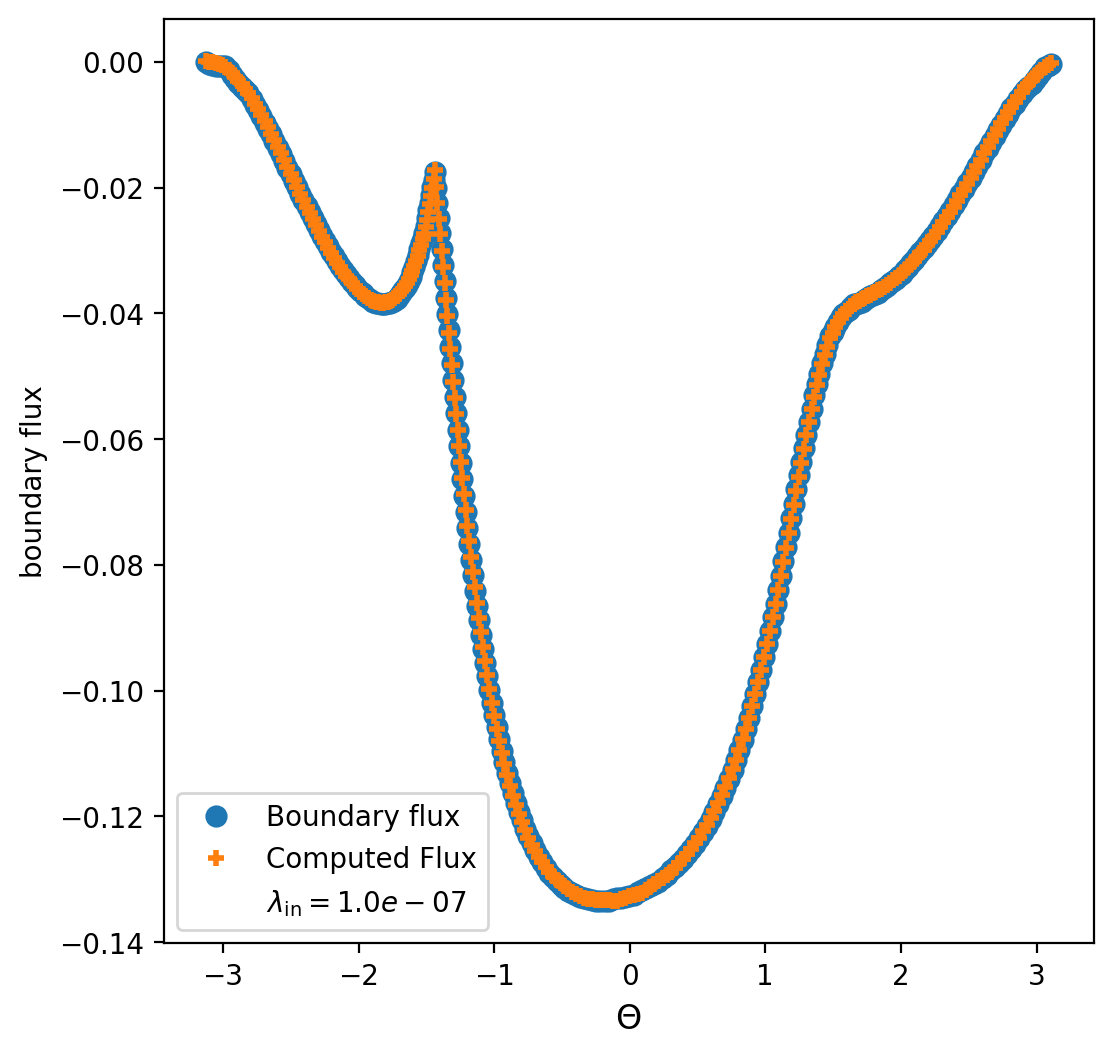

In [ ]:
# Initial guess
top_coils = [5, 20, 65, 115, 155]
radials = [0.1, 0.3, 0.5, 0.2, 0.9]
param_list = top_coils + radials

# Bounds
bounds_coil = [(0, 180)] * len(top_coils)
bounds_radius = [(0, 1)] * len(radials)
bounds = bounds_coil + bounds_radius

# Bounds with 1st coil fixed
#bounds_coil = [(20, 20), (20, 180), (20, 180), (20, 180), (20, 180)]
#bounds_radius = [(0,0), (0, 1), (0, 1), (0, 1), (0, 1)]
#bounds = bounds_coil + bounds_radius

# Parameters
reg_in = 1e-7
omega = 1e-5
dist_th = 5

# optimization
opt_distr, out_cost, final_currents, innercost, fluxerr = opt_PFcoil_loc(param_list, omega, dist_th, bounds, BFGS=True, plot_err=True, reg_in=reg_in)

np.set_printoptions(precision=4, suppress=True)
print("")
print("initial: ", param_list)
print("Optimized: ", opt_distr)
print("flux err: ", fluxerr)
print("outer cost: ", out_cost)
print("inner cost: ", innercost)

### Visualization

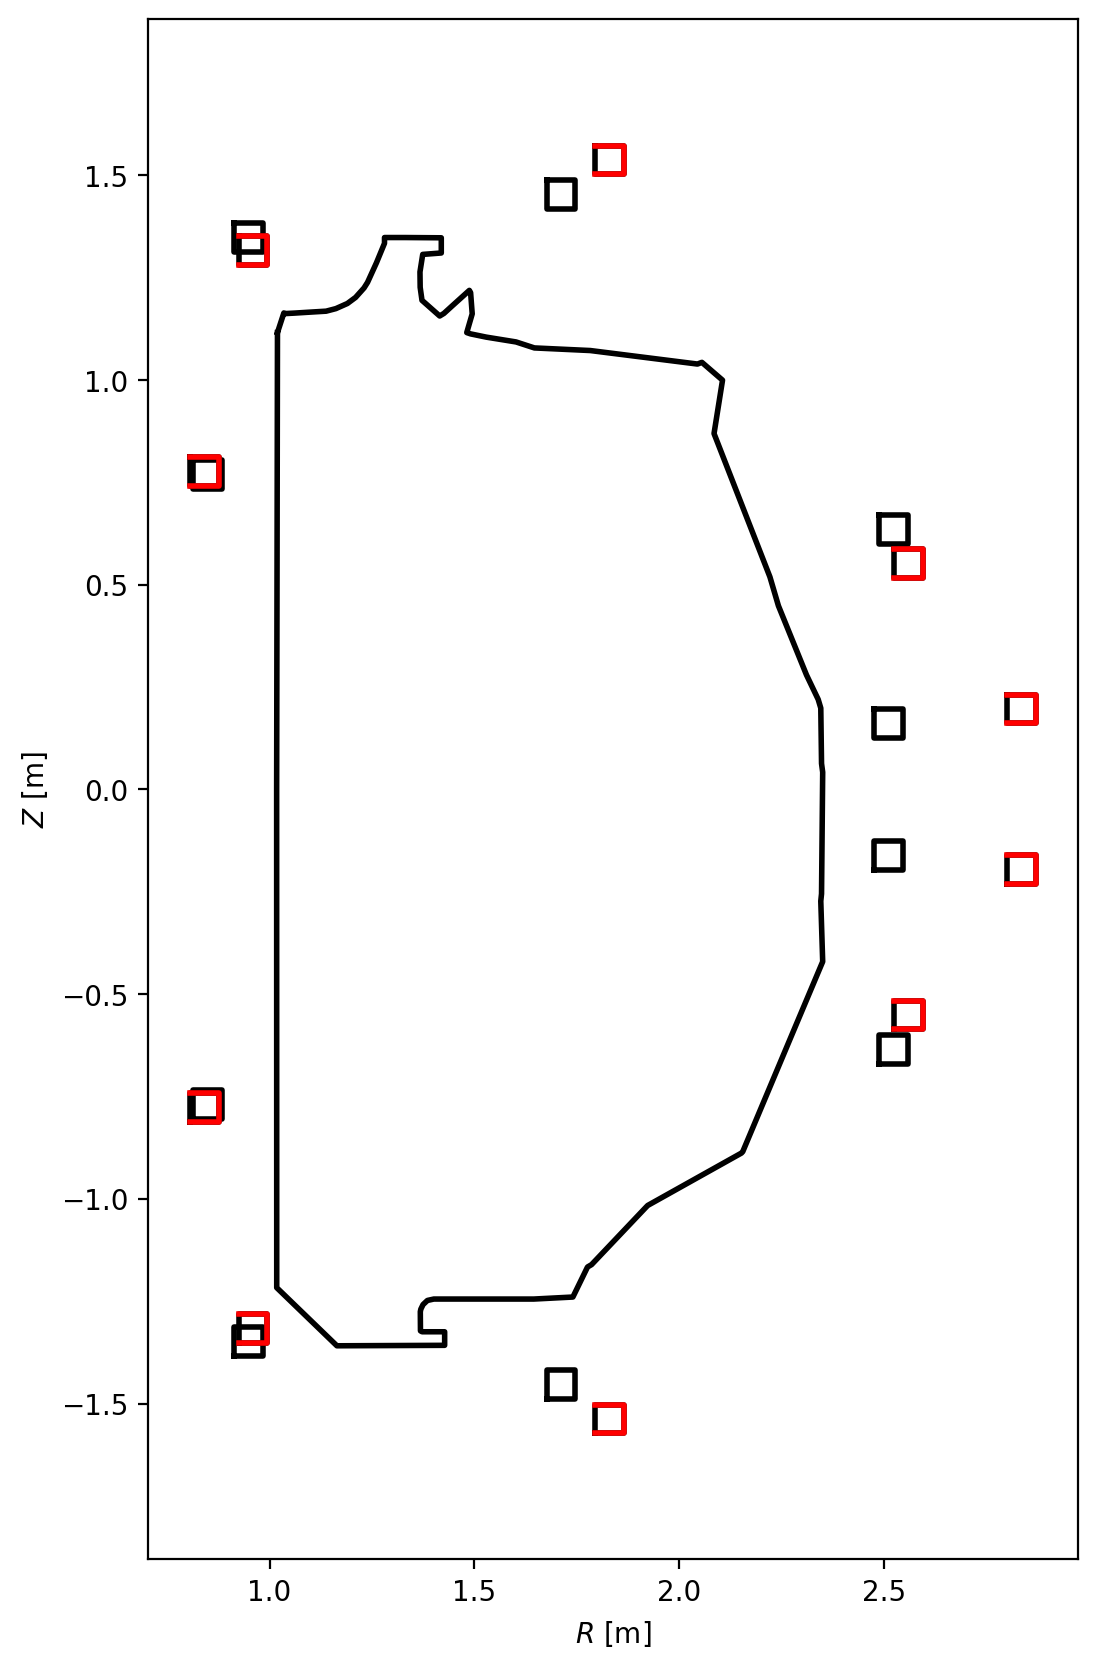

In [ ]:
# dark -> initial guess
# red -> optimized distribution
_ = make_new_coils(param_list, nCoils=5, params2=opt_distr, dx=0.035, dy=0.035)

In [37]:
# smooth penalty function 
# helpful with ML because the model knows the bad areas 


In [38]:
# Global optimization imports
from scipy.stats import qmc
from sklearn.cluster import KMeans
import pandas as pd
from collections import defaultdict

In [84]:
def multi_start_optimization(n_starts, bounds, omega, dist_th, reg_in=1e-7, 
                             sampling_method='lhs', random_seed=42, verbose=True):
    """
    Perform multi-start optimization using Latin Hypercube Sampling or random sampling.
    
    Parameters:
        - n_starts: Number of random starting points
        - bounds: Parameter bounds for optimization
        - omega: Regularization term related to coil distance
        - dist_th: Distance threshold between coils (in degrees)
        - reg_in: Regularization term in inner loop
        - sampling_method: 'lhs' for Latin Hypercube, 'random' for uniform random
        - random_seed: Random seed for reproducibility
        - verbose: Print progress information
    
    Returns:
        - results: Dictionary containing all optimization results
        - best_result: Best optimization result
    """
    np.random.seed(random_seed)
    
    # Number of parameters (angles + radials)
    n_params = len(bounds)
    n_coils = n_params // 2
    
    # Generate starting points
    if sampling_method == 'lhs':
        # Latin Hypercube Sampling
        sampler = qmc.LatinHypercube(d=n_params, seed=random_seed)
        unit_samples = sampler.random(n_starts)
        
        # Transform to parameter bounds
        starting_points = []
        for i in range(n_starts):
            point = []
            for j, (low, high) in enumerate(bounds):
                point.append(low + unit_samples[i, j] * (high - low))
            starting_points.append(point)
    else:
        # Random sampling
        starting_points = []
        for i in range(n_starts):
            point = []
            for low, high in bounds:
                point.append(np.random.uniform(low, high))
            starting_points.append(point)
    
    # Storage for results
    results = {
        'starting_points': starting_points,
        'final_params': [],
        'final_costs': [],
        'final_currents': [],
        'inner_costs': [],
        'flux_errors': [],
        'success': [],
        'n_iterations': [],
        'messages': []
    }
    
    best_cost = float('inf')
    best_result = None
    
    if verbose:
        print(f"Starting multi-start optimization with {n_starts} starts using {sampling_method.upper()}")
        print("=" * 60)
    
    # Run optimization from each starting point
    for i, start_point in enumerate(starting_points):
        if verbose:
            print(f"Start {i+1}/{n_starts}: {np.array(start_point)}")
        
        try:
            opt_params, out_cost, final_curr, inner_cost, flux_err = opt_PFcoil_loc(
                start_point, omega, dist_th, bounds, 
                BFGS=True, plot_err=False, plot_info=False, reg_in=reg_in
            )
            
            # Store results
            results['final_params'].append(opt_params.copy())
            results['final_costs'].append(out_cost)
            results['final_currents'].append(final_curr.copy())
            results['inner_costs'].append(inner_cost)
            results['flux_errors'].append(flux_err)
            results['success'].append(True)
            results['messages'].append('Success')
            
            # Check if this is the best result
            if out_cost < best_cost:
                best_cost = out_cost
                best_result = {
                    'starting_points': start_point,
                    'final_params': opt_params.copy(),
                    'final_cost': out_cost,
                    'final_currents': final_curr.copy(),
                    'inner_cost': inner_cost,
                    'flux_error': flux_err,
                    
                }
            
            if verbose:
                print(f"  → Cost: {out_cost:.6f}, Inner: {inner_cost:.6f}, Flux error: {flux_err:.6f}")
                
        except Exception as e:
            if verbose:
                print(f"  → FAILED: {str(e)}")
            results['final_params'].append(start_point)
            results['final_costs'].append(float('inf'))
            results['final_currents'].append(None)
            results['inner_costs'].append(float('inf'))
            results['flux_errors'].append(float('inf'))
            results['success'].append(False)
            results['messages'].append(str(e))
    
    if verbose:
        success_rate = sum(results['success']) / n_starts * 100
        print(f"\nOptimization Summary:")
        print(f"Success rate: {success_rate:.1f}%")
        print(f"Best cost: {best_cost:.6f}")
        print(f"Best parameters: {best_result['final_params']}")
    
    return results, best_result

In [85]:
# latin hypercube sampling 

number_of_coils = 10

bounds_coil = [(0, 180)] * number_of_coils
bounds_radius = [(0, 1)] * number_of_coils
bounds = bounds_coil + bounds_radius

# Parameters
reg_in = 1e-7
omega = 1e-5
dist_th = 5

n_starts = 10

results, best_result = multi_start_optimization(n_starts, bounds, omega, dist_th, reg_in=reg_in, sampling_method='lhs', random_seed=12, verbose=True)

Starting multi-start optimization with 10 starts using LHS
Start 1/10: [175.4852  90.9584 176.5922 140.7728  65.702   13.8503 113.932  123.9286
  37.8664  20.5537   0.7997   0.2459   0.9893   0.5742   0.7583   0.3546
   0.1532   0.5072   0.5741   0.8812]
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           20     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.81296D-01    |proj g|=  1.82122D-03

At iterate    1    f=  2.81280D-01    |proj g|=  1.82116D-03
  ys=-7.758E-10  -gs= 1.548E-05 BFGS update SKIPPED

At iterate    2    f=  2.74651D-01    |proj g|=  1.79255D-03

At iterate    3    f=  1.48538D-01    |proj g|=  9.87373D-02

At iterate    4    f=  9.89219D-02    |proj g|=  6.13719D-03

At iterate    5    f=  9.58339D-02    |proj g|=  8.50595D-03

At iterate    6    f=  9.30305D-02    |proj g|=  2.25753D-03

At iterate    7    f=  9.21332D-02    |proj g|=  1.23085D-03

At iterate    8    f=  8.7543

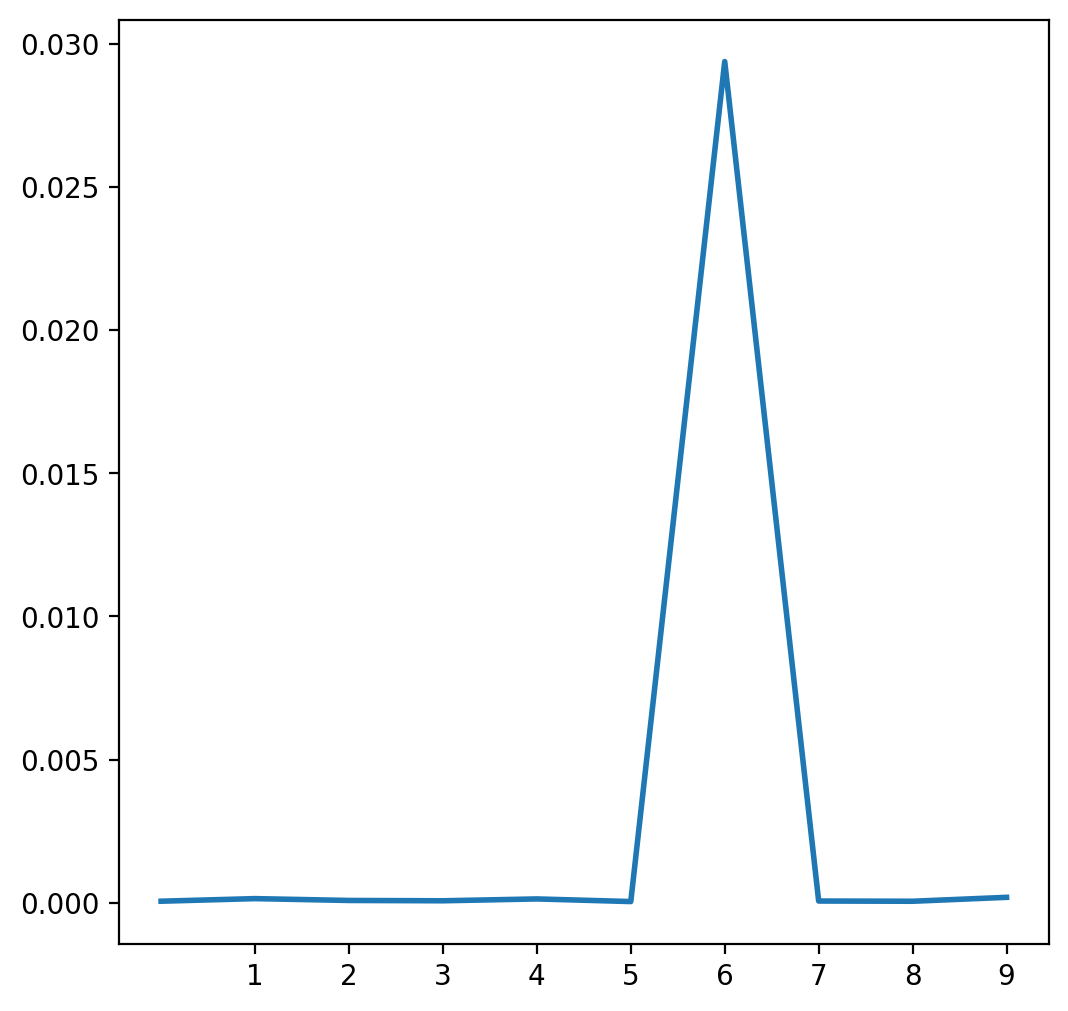

In [86]:
plt.plot(results['final_costs'])
plt.xticks(range(1,n_starts))
plt.show()

[np.float64(92.52768297548253), np.float64(8.36224563707386), np.float64(94.04107261568626), np.float64(12.726965473444437), np.float64(105.29766647774655), np.float64(122.59610536226343), np.float64(89.87256100637202), np.float64(88.71825186280107), np.float64(148.47950166321803), np.float64(145.7402094164056), np.float64(0.6942745440383337), np.float64(0.12790711393731097), np.float64(0.82223398763141), np.float64(0.731877268611018), np.float64(0.8500996468591504), np.float64(0.15144819293278652), np.float64(0.9305331258554533), np.float64(0.4754947325097166), np.float64(0.9247416110051798), np.float64(0.680768792667228)]


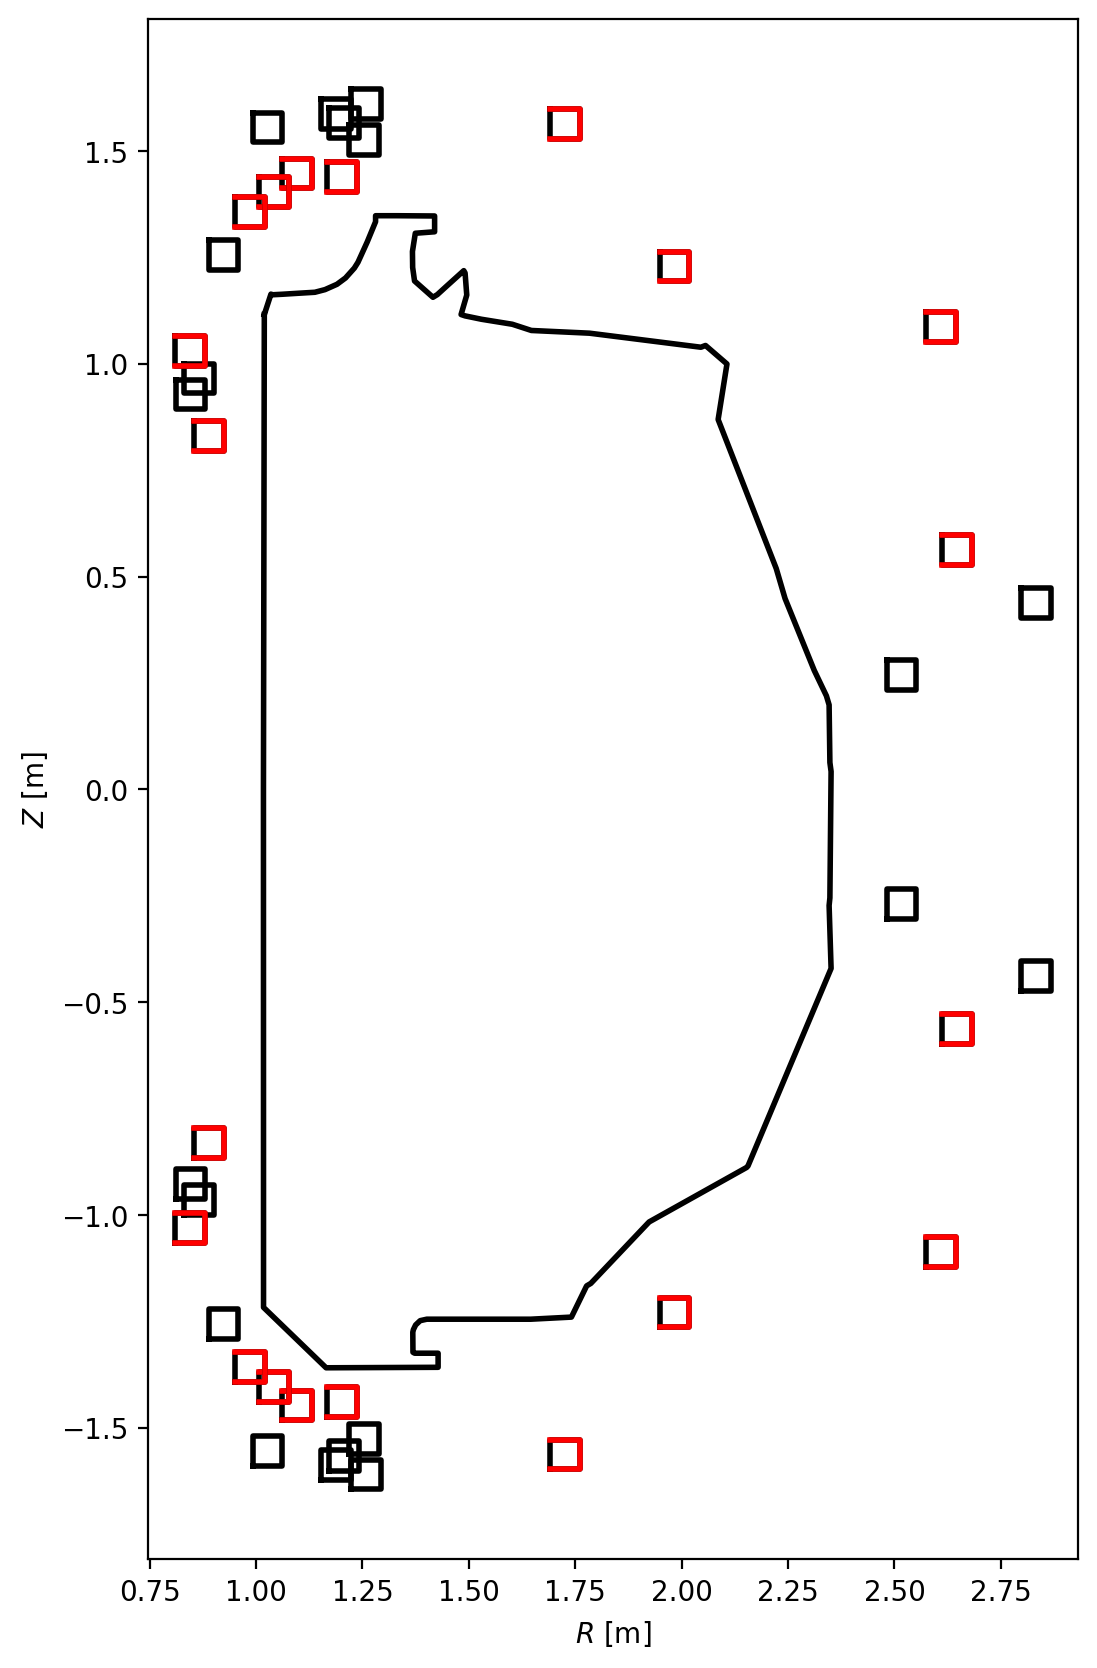

In [87]:
# black -> initial guess
# red -> optimized distribution
opt_distr = best_result['final_params']
param_list = best_result['starting_points']

print(param_list)

_ = make_new_coils(param_list, nCoils=number_of_coils, params2=opt_distr, dx=0.035, dy=0.035)